# マルチンゲール

## ポアソン過程のシミュレーション

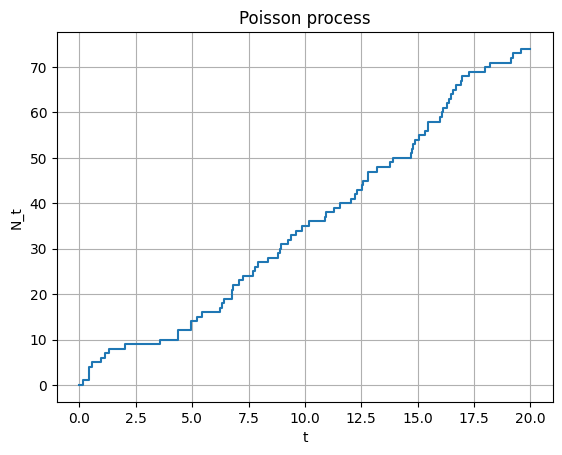

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# パラメータ
lam = 4.0  # 単位時間あたり平均2回
T = 20.0  # t=10まで観測

rng = np.random.default_rng(0)

# 到着時刻を生成
arrival_times = []
t = 0.0

while True:
    waiting_time = rng.exponential(scale=1 / lam)
    t += waiting_time

    if t > T:
        break

    arrival_times.append(t)

arrival_times = np.array(arrival_times)

# N_t を階段状に描画
times = np.concatenate(([0], arrival_times, [T]))
counts = np.concatenate((
    [0],
    np.arange(1, len(arrival_times) + 1),
    [len(arrival_times)],
))

plt.step(times, counts, where="post")
plt.xlabel("t")
plt.ylabel("N_t")
plt.title("Poisson process")
plt.grid()

plt.show()

In [5]:
arrival_times

array([ 0.16998298,  0.42488225,  0.42983392,  0.43040125,  0.56798697,
        0.97547208,  1.14386781,  1.33269315,  2.03688965,  3.55132792,
        4.37293498,  4.37325692,  4.94053059,  4.95865501,  5.22600508,
        5.43823834,  6.2257155 ,  6.31421801,  6.3909958 ,  6.76405065,
        6.7733017 ,  6.8071344 ,  7.06468393,  7.25832099,  7.69274061,
        7.79615814,  7.90821083,  8.37123391,  8.80253732,  8.88340214,
        8.93609249,  9.24191598,  9.37649703,  9.5901683 ,  9.85234886,
       10.16039152, 10.89243385, 10.93085604, 11.29730726, 11.57836665,
       12.05287925, 12.20262725, 12.31979841, 12.52407524, 12.59019256,
       12.77664818, 12.8031637 , 13.21490054, 13.78471009, 13.92273571,
       14.71341844, 14.7403441 , 14.8102298 , 14.88454197, 15.0754312 ,
       15.30936752, 15.44335322, 15.47449173, 15.97398957, 16.09835555,
       16.12674803, 16.31955713, 16.39368204, 16.49766258, 16.56063029,
       16.6894219 , 16.93884806, 16.96305435, 17.25868671, 17.97

期待値 
$
E[N_t] = \lambda * t
$

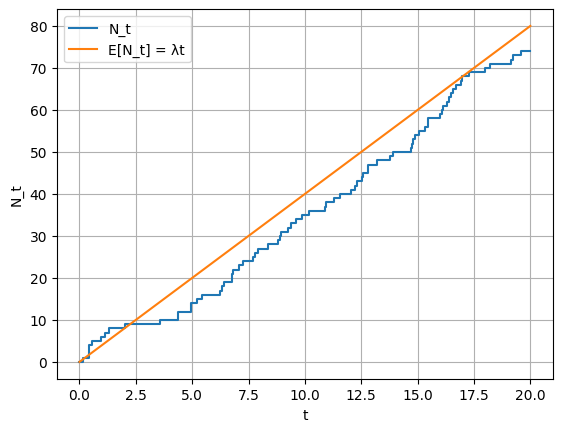

In [ ]:
t_line = np.linspace(0, T, 200)
expected = lam * t_line

# 描画
plt.step(times, counts, where="post", label="N_t")
plt.plot(t_line, expected, label="E[N_t] = λt")

plt.xlabel("t")
plt.ylabel("N_t")
plt.legend()
plt.grid()
plt.show()

## マルチンゲールなポアソン過程のシミュレーション

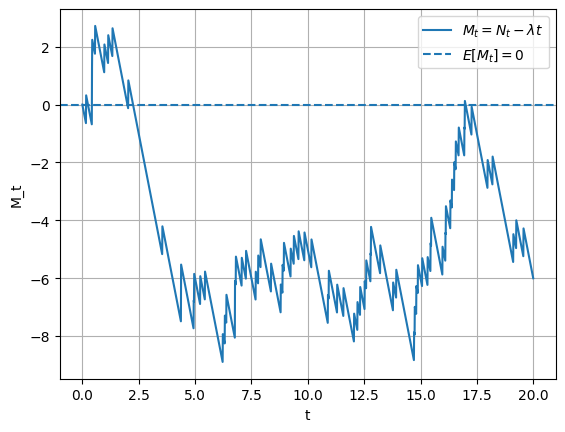

In [7]:
# 時刻を細かく区切る
t_grid = np.linspace(0, T, 2000)

# 各時刻までに何回イベントが起きたか
N_t = np.searchsorted(arrival_times, t_grid, side="right")

# 補償されたポアソン過程
M_t = N_t - lam * t_grid

plt.plot(t_grid, M_t, label=r"$M_t=N_t-\lambda t$")
plt.axhline(0, linestyle="--", label=r"$E[M_t]=0$")

plt.xlabel("t")
plt.ylabel("M_t")
plt.legend()
plt.grid()
plt.show()

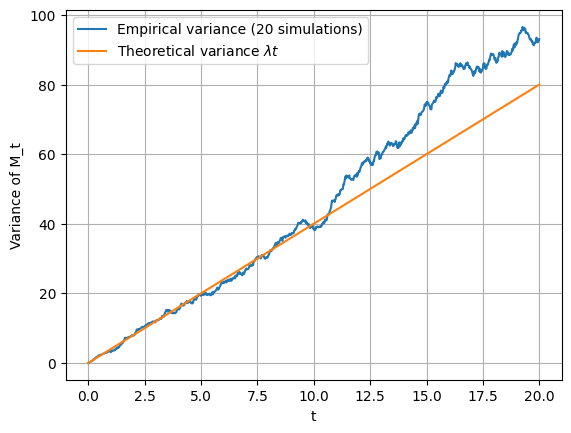

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lam = 4.0
T = 20.0
n_sim = 100

rng = np.random.default_rng(0)

# 評価する時刻
t_grid = np.linspace(0, T, 1000)

# 各シミュレーションの M_t を保存
M_all = np.zeros((n_sim, len(t_grid)))

for i in range(n_sim):
    # ポアソン過程の到着時刻を生成
    arrival_times = []
    t = 0.0

    while True:
        waiting_time = rng.exponential(scale=1 / lam)
        t += waiting_time

        if t > T:
            break

        arrival_times.append(t)

    arrival_times = np.array(arrival_times)

    # N_t
    N_t = np.searchsorted(arrival_times, t_grid, side="right")

    # M_t = N_t - lambda t
    M_all[i] = N_t - lam * t_grid


# 20本から標本分散を計算
empirical_var = np.var(M_all, axis=0, ddof=1)

# 理論分散
theoretical_var = lam * t_grid

# 描画
plt.plot(t_grid, empirical_var, label="Empirical variance (20 simulations)")

plt.plot(t_grid, theoretical_var, label=r"Theoretical variance $\lambda t$")

plt.xlabel("t")
plt.ylabel("Variance of M_t")
plt.legend()
plt.grid()
plt.show()

In [11]:
print("Empirical variance at t=20 :", empirical_var[-1])
print("Theoretical variance at t=20:", lam * T)

Empirical variance at t=20 : 93.0707070707071
Theoretical variance at t=20: 80.0


$$
M_t = \exp{ \{\lambda N_t - \lambda (e^{\lambda} - 1 ) t \}}
$$

> 現在 $M_s$ にいることまで分かったうえで、未来の $M_t$ を予測しても、その条件付き期待値は現在値 $M_s$ のまま

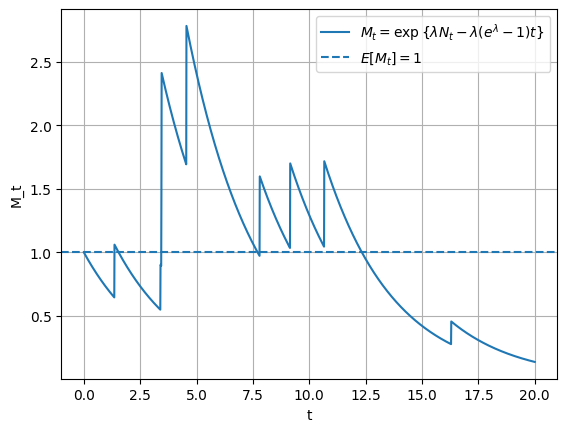

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lam = 0.5
T = 20.0

rng = np.random.default_rng(0)

# ポアソン過程の到着時刻を生成
arrival_times = []
t = 0.0

while True:
    waiting_time = rng.exponential(scale=1 / lam)
    t += waiting_time

    if t > T:
        break

    arrival_times.append(t)

arrival_times = np.array(arrival_times)

# 時刻グリッド
t_grid = np.linspace(0, T, 2000)

# N_t
N_t = np.searchsorted(arrival_times, t_grid, side="right")

# 指数マルチンゲール
M_t = np.exp(lam * N_t - lam * (np.exp(lam) - 1) * t_grid)

# 描画
plt.plot(t_grid, M_t, label=r"$M_t=\exp\{\lambda N_t-\lambda(e^\lambda-1)t\}$")

plt.axhline(1, linestyle="--", label=r"$E[M_t]=1$")

plt.xlabel("t")
plt.ylabel("M_t")
plt.legend()
plt.grid()
plt.show()

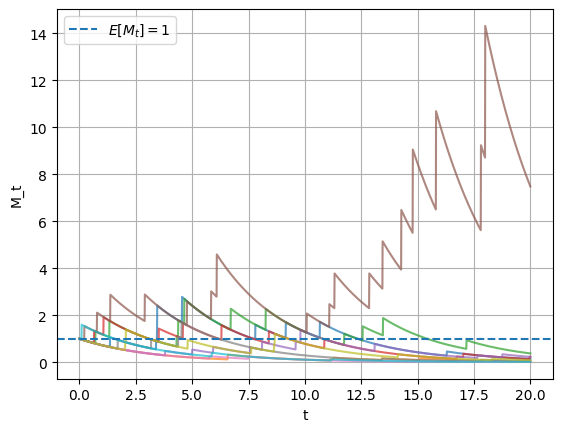

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lam = 0.5
T = 20.0
n_sim = 100
n_steps = 2000

rng = np.random.default_rng(0)

t_grid = np.linspace(0, T, n_steps)

M_all = np.zeros((n_sim, n_steps))

for i in range(n_sim):
    arrival_times = []
    t = 0.0

    while True:
        waiting_time = rng.exponential(scale=1 / lam)
        t += waiting_time

        if t > T:
            break

        arrival_times.append(t)

    arrival_times = np.array(arrival_times)

    N_t = np.searchsorted(arrival_times, t_grid, side="right")

    M_all[i] = np.exp(lam * N_t - lam * (np.exp(lam) - 1) * t_grid)


# 10経路だけ表示
for i in range(10):
    plt.plot(t_grid, M_all[i], alpha=0.7)

plt.axhline(1, linestyle="--", label=r"$E[M_t]=1$")

plt.xlabel("t")
plt.ylabel("M_t")
plt.legend()
plt.grid()
plt.show()